In [209]:
# Importar librerías
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
from math import sqrt, asin, erf, sqrt as _sqrt

# Cargar archivo
df_log  = pd.read_table('../datasets/logs_exp_us.csv')

In [210]:
# Preparación de los datos
# Renombrar las columnas 
df_log.columns = ['eventname', 'device', 'event', 'group']

# Cambiar los tipos de datos
df_log['event'] = pd.to_datetime(df_log['event'], unit='s', utc=True, errors='coerce')
df_log['eventname'] = df_log['eventname'].astype('string')
df_log['device'] = df_log['device'].astype('string')

# Mapear los valores de los grupos
map_groups = {246:'A1', 247: 'A2', 248:'B'}
df_log['group'] = df_log['group'].map(map_groups).astype('string')

# Eliminar duplicados
df_log = df_log.dropna(subset=['device']).drop_duplicates(subset=['device', 'event', 'eventname', 'group'])

# Crear una columna que contenga solo la fecha
#df_log['date'] = df_log['event'].dt.floor('D')
df_log['date'] = df_log['event'].dt.date

df_log['eventname'] = df_log['eventname'].str.strip()

In [211]:
# Cuántos eventos hay en los registros?
print(f"Total de eventos registrados: { df_log.shape[0]:,}")

Total de eventos registrados: 243,713


In [212]:
# ¿Cuántos eventos por tipo?
print(df_log['eventname']
      .value_counts(dropna=False)
      .rename_axis('eventname')
      .reset_index(name='events'))

                 eventname  events
0         MainScreenAppear  119101
1       OffersScreenAppear   46808
2         CartScreenAppear   42668
3  PaymentScreenSuccessful   34118
4                 Tutorial    1018


In [213]:
# ¿Cuántos usuarios hay en los registros? (Se considera cada device = usuario)
print(f"Usuarios únicos (total): {df_log['device'].dropna().nunique()}")

Usuarios únicos (total): 7551


In [214]:
# ¿Cuál es el promedio de eventos por usuario?
df_events_per_user = df_log.groupby('device', as_index=False).size().rename(columns={'size':'events'})
print(f"Cantidad promedio de eventos por usuario: {df_events_per_user['events'].mean():2f}")

Cantidad promedio de eventos por usuario: 32.275593


Rango: 2019-07-25 - 2019-08-07


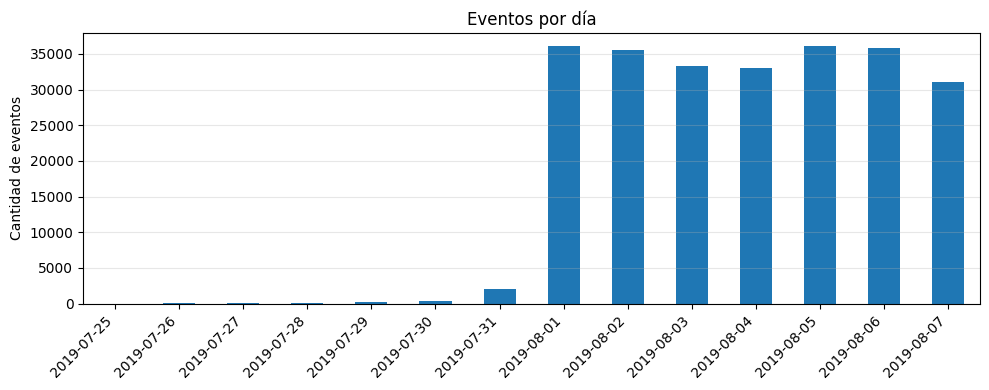

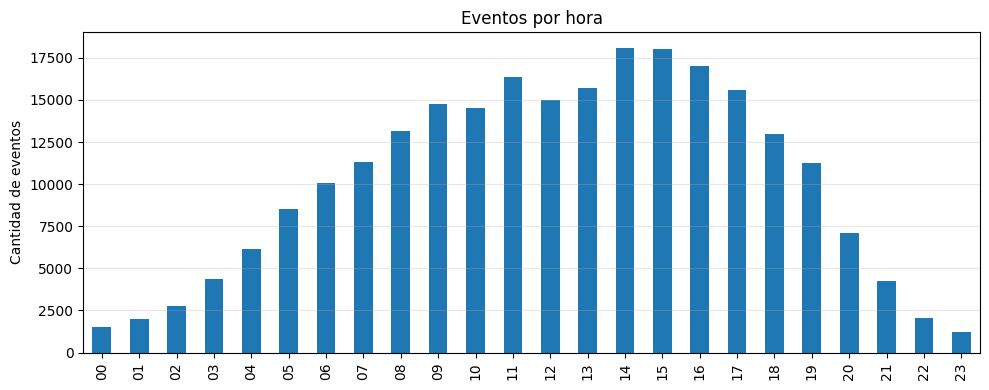

In [215]:
# Encuentra la fecha máxima y mínima
print(f"Rango: {df_log['date'].min()} - {df_log['date'].max()}")

# Eventos por día
daily_counts = df_log.groupby('date').size()

plt.figure(figsize=(10, 4))
ax = daily_counts.plot(kind='bar')
ax.set_title('Eventos por día')

ax.set_ylabel('Cantidad de eventos')
ax.set_xlabel('')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Eventos por hora
hour_counts = df_log['event'].dt.hour.value_counts().sort_index()

plt.figure(figsize=(10, 4))
ax = hour_counts.plot(kind='bar')
ax.set_title('Eventos por hora')
ax.set_xlabel('')
ax.set_ylabel('Cantidad de eventos')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [216]:
#Contar eventos por día (DAU) (dispositivos únicos)
df_daily = (df_log.dropna(subset=['date']).groupby('date', as_index=False).agg(events=('eventname','size'),dau=('device', 'nunique'))).sort_values('date').reset_index(drop=True)

# Estimar un nivel base con la mediana de los últimos 7 días
# Nivel base = mediana de los últimos 7 días observados
df_inicio = df_daily['date'].max() - pd.Timedelta(days=6)
baseline = df_daily.loc[df_daily['date'] >= df_inicio, 'events'].median()

# Umbral de detección de racha (>= 3 días coinsecutivos sobre el umbral)
umbral = 0.90 * baseline

df_ok = df_daily['events'] >= umbral

# Tomar como inicio el primer día con al menos 3 días consecutivos por arriba del umbral.
# id de rachas (True / False) y longitud de racha para True. 
gid = (df_ok != df_ok.shift()).cumsum()
df_runlen = df_ok.groupby(gid).cumsum()
df_daily['ok'] = df_ok
df_daily['run'] = df_runlen
 
# Primer día "completo" por nivel de eventos
start_date = df_daily.loc[(df_daily['ok']) & (df_daily['run'] >=1),'date'].iloc[0]

# Verificar desde cuándo existen todos los grupos del experimento
groups_per_day = df_log.groupby('date')['group'].nunique().sort_index()

# Obtener la primer fecha en donde existen los 3 grupos (A1, A2 y B)
start_all_groups = groups_per_day[groups_per_day == 3].index.min()
start_final = max(start_date, start_all_groups)
end_final = df_log['date'].max()

# Obtener el nuevo dataframe filtrado con los datos reales.
df_stable = df_log[(df_log['date'] >= start_final) & (df_log['date'] <= end_final)].copy()

print(f"Periodo de datos completos: {start_final} - {end_final}")

Periodo de datos completos: 2019-08-01 - 2019-08-07


In [217]:
print('Registros eliminados de la fuente original:', df_log.shape[0] - df_stable.shape[0])

Registros eliminados de la fuente original: 2826


In [218]:
# Estudio del embudo de eventos
# Observa qué eventos hay en los registros y su frecuencia de suceso. Ordénalos por frecuencia.

# Obtener la cantidad de eventos 
df_events = df_stable['eventname'].value_counts(dropna=False).rename_axis('eventname').reset_index(name='events')

# Obtener el porcentaje de ocurrencias de cada evento.
df_events['percent_events'] = (df_events['events'] / len(df_stable) * 100).round(2)

print(df_events)

                 eventname  events  percent_events
0         MainScreenAppear  117328           48.71
1       OffersScreenAppear   46333           19.23
2         CartScreenAppear   42303           17.56
3  PaymentScreenSuccessful   33918           14.08
4                 Tutorial    1005            0.42


In [219]:
# Encuentra la cantidad de usuarios que realizaron cada una de estas acciones. 
# Ordena los eventos por el número de usuarios.
# Calcula la proporción de usuarios que realizaron la acción al menos una vez.

# Obtener el total de usuarios (devices únicos)
total_users = df_stable['device'].nunique()

# Obtener usuarios que realizaron cada evento (al menos una vez)
df_users_by_event = df_stable.groupby('eventname')['device'].nunique().reset_index(name='users').sort_values('users', ascending = False).reset_index(drop=True)

# Obtener la proporcion respecto del total de usuarios
df_users_by_event['user_share'] = df_users_by_event['users'] / total_users
df_users_by_event['user_share_%'] = (df_users_by_event['user_share'] * 100).round(2)

print(df_users_by_event)

                 eventname  users  user_share  user_share_%
0         MainScreenAppear   7419    0.984736         98.47
1       OffersScreenAppear   4593    0.609636         60.96
2         CartScreenAppear   3734    0.495620         49.56
3  PaymentScreenSuccessful   3539    0.469737         46.97
4                 Tutorial    840    0.111495         11.15


¿En qué orden crees que ocurrieron las acciones? ¿Todas son parte de una sola secuencia? No es necesario tenerlas en cuenta al calcular el embudo.

El orden de los eventos (por la descripción de cada uno de ellos) sería según mi lógica:
- MainScreenAppear (Pantalla principal se despliega)
- OffersScreenAppear (Pantalla de oferta se despliega)
- CartScreenAppear (Pantalla de carrito se despliega)
- PaymentScreenSuccessful (Pantalla de pago exitoso)
- Tutorial (Sin relación con el proceso)

¿Todas son parte de una sola secuencia?
- No, ya que vemos que la pantalla del tutorial no es mandatoria para poder realizar una compra.

In [220]:
# Utiliza el embudo de eventos para encontrar la proporción de usuarios que pasan de una etapa a la siguiente. 
# Por ejemplo, para la secuencia de eventos A → B → C, calcula la proporción de usuarios en la etapa B 
# a la cantidad de usuarios en la etapa A y la proporción de usuarios en la etapa C a la cantidad en la etapa B.

# Sacar los eventos a una lista
events = df_users_by_event['eventname'].tolist()

# Borrar el último registro (Tutorial), porque no es parte del proceso del embudo
del events[-1]

# Obtener la cantidad de eventos
u = df_stable.groupby('eventname')['device'].nunique().reindex(events)

funnel = []
for i in range(len(events) - 1):
    a, b = events[i], events[i + 1]
    users_a, users_b = u[a], u[b]
    step_conv = users_b / users_a
    funnel.append({'from ':a, 'to': b, 'users_from': users_a, 'users_to': users_b, 'step_conversion': round(step_conv*100,2), 'drop_off':round((1-step_conv)*100,2)})
    
# Crear el dataframe en base a la lista formada
df_funnel = pd.DataFrame(funnel)

#Proporcion de usuarios que van desde el paso 1 hasta el carrito de compra
cumulative_main_to_cart = u['CartScreenAppear'] / u['MainScreenAppear']

#Proporcion de usuarios que van dese el paso 1 hasta concretar el pago
cumulative_main_to_payment = u['PaymentScreenSuccessful'] / u['MainScreenAppear']

print(df_funnel)

print(f"\nDe página principal a ventana de carrito: {cumulative_main_to_cart*100:.2f}%")
print(f"De página principal a ventana de pago: {cumulative_main_to_payment*100:.2f}%")

                from                        to  users_from  users_to  \
0    MainScreenAppear       OffersScreenAppear        7419      4593   
1  OffersScreenAppear         CartScreenAppear        4593      3734   
2    CartScreenAppear  PaymentScreenSuccessful        3734      3539   

   step_conversion  drop_off  
0            61.91     38.09  
1            81.30     18.70  
2            94.78      5.22  

De página principal a ventana de carrito: 50.33%
De página principal a ventana de pago: 47.70%


- ¿En qué etapa se pierden más usuarios?
    - La mayor fuga de usuarios se da en la ventana de ofertas. !38% de los usuarios ahí se van!

- ¿Qué porcentaje de usuarios hace todo el viaje desde su primer evento hasta el pago?
    - 47% de los usuarios completan el ciclo de compra, !casi la mitad de los usuario1

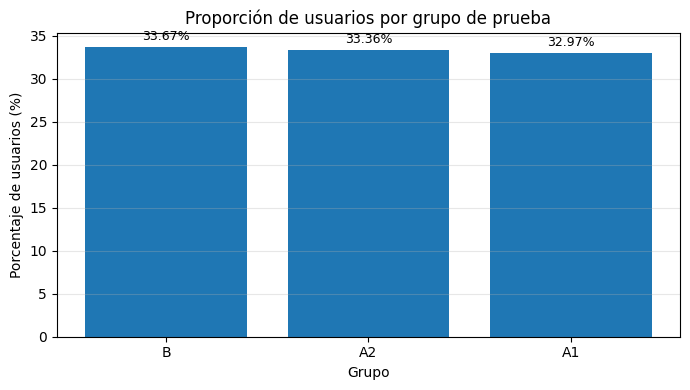

In [221]:
# Observa si hay una diferencia estadísticamente significativa entre las muestras A1/A2/B

# Obtener los usuarios (devices) por grupo
df_users = df_stable[['device', 'group']]

# Obtener la cantidad de usuarios por grupo.
df_user_by_group = df_users.groupby('group', as_index=False)['device'].nunique().rename(columns={'device':'users'}).sort_values('users', ascending=False).reset_index(drop=True)

# Obtener la cantidad de usuarios totales
total_users = df_users['device'].nunique()

# Obtener la proporción de cada grupo
df_user_by_group['user_share'] = df_user_by_group['users'] / total_users

# Obtener la proporción (en porcentaje) de cada grupo
df_user_by_group['user_share_%'] = (df_user_by_group['user_share'] * 100).round(2)

# Graficar proporción de grupos
plt.figure(figsize=(7,4))
plt.bar(df_user_by_group['group'], df_user_by_group['user_share'] * 100)
plt.ylabel('Porcentaje de usuarios (%)')
plt.xlabel('Grupo')
plt.title('Proporción de usuarios por grupo de prueba')
plt.grid(axis='y', alpha=0.3)

# Agregarles los rótulos a las barras de los grupos
for i, v in enumerate(df_user_by_group['user_share_%']):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [222]:
# Selecciona el evento más popular en cada uno de los grupos de control y encontrar la proporción de usuarios que relizaron dicha acción. 

# Obtener los usuarios que hicieron cada envento en cada grupo
df_users_per_event_group = df_stable.groupby(['group','eventname'])['device'].nunique().rename('users').reset_index()

# Definir los grupos de control
control_groups = ['A1', 'A2']

# Obtener la cantidad de usuarios por grupo de control 
df_ctrl = df_users_per_event_group[df_users_per_event_group['group'].isin(control_groups)]

# Obtener el total de usuarios de cada grupo
df_total_users_ctrl = df_stable[df_stable['group'].isin(control_groups)].groupby('group')['device'].nunique().rename('total_users').reset_index()

# Unir los dataframes y dejarlo listo para sacar la proporción.
df_ctrl = df_ctrl.merge(df_total_users_ctrl, on='group', how='left')

# Obtener la proporción de usuarios por grupo entre el total de usuarios
df_ctrl['user_share_%'] = (df_ctrl['users'] / df_ctrl['total_users'] * 100).round(2)

# Obtener valor mayor de usuarios por grupo
max_users_per_group = df_ctrl.groupby('group')['users'].transform('max')

# Obtener el top 1 de eventos por grupo
df_top = df_ctrl[df_ctrl['users'] == max_users_per_group].sort_values(['group', 'users'], ascending=[True,False]).reset_index(drop=True)

print(df_top[['group', 'eventname', 'users', 'user_share_%']])

  group         eventname  users  user_share_%
0    A1  MainScreenAppear   2450         98.63
1    A2  MainScreenAppear   2476         98.53


In [223]:
# Crear una función para evaluar los demás eventos de forma automática

def _2prop_ztest (s1, t1, s2, t2, continuity = False):    
    # S1 = Satisfactorio G1 (Numero de usuarios únicos de G1 que hicieron el evento más de una vez)
    # T1 = Total de usuarios G1 (Numero total de usuarios en G1)
    
    # S2 = Satisfactorio G2 (Numero de usuarios únicos de G2 que hicieron el evento más de una vez)
    # T2 = Total de usuarios G2 (Numero total de usuarios en G2)
    
    if s1 in (0,t1) or s2 in (0, t2):
        s1 += .5
        s2 += .5
        t1 += 1
        t2 += 1
    
    p1 = s1 / t1
    p2= s2 / t2    
    p = (s1+s2) / (t1+t2)
    
    se = sqrt(p*(1-p) * (1/t1 + 1/t2))
    if continuity:
        z = (abs(p1-p2)-.5 * (1/t1 + 1/t2))/se
        z = np.sign(p1-p2) * max(z,0)
    else:
        z = (p1-p2)/se
        
    # p-valor bilateral (aprox normal)
    pval = 2*(1-.5 * (1 + erf(abs(z) /_sqrt(2))))
    
    # IC95% del diferencia con SE no-pool 
    se_unpooled = sqrt(p1*(1-p1)/t1 + p2*(1-p2)/t2)
    ci_low = (p1-p2) - 1.96 * se_unpooled
    ci_high = (p1-p2) + 1.96 * se_unpooled
    
    # Tamaño del efecto
    h = 2*asin(np.sqrt(p1)) - 2*asin(np.sqrt(p2))
    
    return p1,p2,(p1-p2),z,pval, ci_low, ci_high,h

def _fdr_bh(pvals):
    """Benjamini–Hochberg q-values (FDR). Devuelve arreglo de q-values."""
    p = np.asarray(pvals, float)
    n = p.size
    order = np.argsort(p)
    ranked = p[order]
    q = np.empty(n, float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        q[i] = min(prev, ranked[i] * n / (i+1))
        prev = q[i]
    qvals = np.empty(n, float); qvals[order] = q
    return qvals

def compare_events_between_groups(df, group_a='A1', group_b='A2',
                                  group_col='group', device_col='device', event_col='eventname',
                                  adjust='bh'):
    """
    Compara proporciones de usuarios que realizaron cada evento (≥1 vez) entre group_a vs group_b.
    Devuelve DataFrame con conteos, tasas, diferencial, z, p, IC95%, h y q-value (si adjust='bh').
    """
    # Totales de usuarios por grupo (denominadores)
    totals = (df[[group_col, device_col]].drop_duplicates()
              .groupby(group_col)[device_col].nunique())

    n1 = int(totals.get(group_a, 0))
    n2 = int(totals.get(group_b, 0))

    # Éxitos por evento y grupo (usuarios únicos que hicieron el evento)
    counts = (df.groupby([group_col, event_col])[device_col]
                .nunique()
                .rename('users')
                .reset_index())

    ev_a = counts[counts[group_col] == group_a].set_index(event_col)['users']
    ev_b = counts[counts[group_col] == group_b].set_index(event_col)['users']

    # Unión de todos los eventos presentes en cualquiera de los dos grupos
    all_events = sorted(set(ev_a.index).union(set(ev_b.index)))

    rows = []
    for e in all_events:
        s1 = int(ev_a.get(e, 0))
        s2 = int(ev_b.get(e, 0))
        p1, p2, diff, z, pval, ci_low, ci_high, h = _2prop_ztest(s1, n1, s2, n2)
        rows.append({
            'eventname': e,
            f'users_{group_a}': s1, f'total_{group_a}': n1, f'rate_{group_a}': p1,
            f'users_{group_b}': s2, f'total_{group_b}': n2, f'rate_{group_b}': p2,
            'diff_(A-B)': diff, 'z': z, 'pval': pval,
            'ci95_low': ci_low, 'ci95_high': ci_high, 'cohens_h': h
        })

    out = pd.DataFrame(rows).sort_values('pval').reset_index(drop=True)

    if adjust == 'bh' and len(out) > 1:
        out['qval_bh'] = _fdr_bh(out['pval'].values)
        out['sig_bh_0.05'] = out['qval_bh'] <= 0.05

    # Bandera de significancia cruda
    out['sig_p_0.05'] = out['pval'] <= 0.05

    # Formatea tasas en %
    for col in [f'rate_{group_a}', f'rate_{group_b}', 'diff_(A-B)', 'ci95_low', 'ci95_high']:
        out[col] = (out[col] * 100).round(2)

    return out

In [230]:
# Ejecutar la función (Todos los eventos (A1 vs A2))
res_all_ctrl = compare_events_between_groups(df_stable, 'A1', 'A2', adjust='bh')
print(res_all_ctrl)

                 eventname  users_A1  total_A1  rate_A1  users_A2  total_A2  \
0  PaymentScreenSuccessful      1200      2484    48.31      1158      2513   
1         CartScreenAppear      1266      2484    50.97      1238      2513   
2       OffersScreenAppear      1542      2484    62.08      1520      2513   
3         MainScreenAppear      2450      2484    98.63      2476      2513   
4                 Tutorial       278      2484    11.19       283      2513   

   rate_A2  diff_(A-B)         z      pval  ci95_low  ci95_high  cohens_h  \
0    46.08        2.23  1.577995  0.114567     -0.54       5.00  0.044650   
1    49.26        1.70  1.203369  0.228834     -1.07       4.47  0.034049   
2    60.49        1.59  1.154988  0.248095     -1.11       4.29  0.032681   
3    98.53        0.10  0.309344  0.757060     -0.55       0.76  0.008755   
4    11.26       -0.07 -0.078161  0.937700     -1.82       1.68 -0.002211   

    qval_bh  sig_bh_0.05  sig_p_0.05  
0  0.413492        Fals

### Interpretación:
- Todos los p-values > 0.11 y q-values ≥ 0.41, no existe por tanto ninguna diferencia significativa
- A1 vs A2 no difieren en nada importante, por lo que pueden considerarse en un grupo único de control.

In [ ]:
# Ejecutar la función (Todos los eventos (A1 vs B))
res_a1_b = compare_events_between_groups(df_stable, 'A1', 'B')
print(res_a1_b)

                 eventname  users_A1  total_A1  rate_A1  users_B  total_B  \
0         CartScreenAppear      1266      2484    50.97     1230     2537   
1       OffersScreenAppear      1542      2484    62.08     1531     2537   
2  PaymentScreenSuccessful      1200      2484    48.31     1181     2537   
3         MainScreenAppear      2450      2484    98.63     2493     2537   
4                 Tutorial       278      2484    11.19      279     2537   

   rate_B  diff_(A-B)         z      pval  ci95_low  ci95_high  cohens_h  \
0   48.48        2.48  1.759874  0.078429     -0.28       5.25  0.049680   
1   60.35        1.73  1.258082  0.208362     -0.96       4.43  0.035515   
2   46.55        1.76  1.247388  0.212255     -1.00       4.52  0.035211   
3   98.27        0.37  1.047276  0.294972     -0.32       1.05  0.029630   
4   11.00        0.19  0.219283  0.826429     -1.54       1.93  0.006189   

    qval_bh  sig_bh_0.05  sig_p_0.05  
0  0.353759        False       False  
1 

### Interpretación:
- Comparando A1 vs B en todos los eventos, las diferencias son pequeñas y no significativas (p >= 0.078); Acorde a los datos que tenemos, los usuarios navegan igual con la fuente nueva y la anterior; estadísticamente son comparables.

In [ ]:
# Ejecutar la función (Todos los eventos (A2 vs B))
res_a2_b = compare_events_between_groups(df_stable, 'A2', 'B')
print(res_a2_b)

                 eventname  users_A2  total_A2  rate_A2  users_B  total_B  \
0         MainScreenAppear      2476      2513    98.53     2493     2537   
1         CartScreenAppear      1238      2513    49.26     1230     2537   
2  PaymentScreenSuccessful      1158      2513    46.08     1181     2537   
3                 Tutorial       283      2513    11.26      279     2537   
4       OffersScreenAppear      1520      2513    60.49     1531     2537   

   rate_B  diff_(A-B)         z      pval  ci95_low  ci95_high  cohens_h  \
0   98.27        0.26  0.740980  0.458705     -0.43       0.95  0.020876   
1   48.48        0.78  0.555402  0.578620     -1.98       3.54  0.015631   
2   46.55       -0.47 -0.335376  0.737342     -3.22       2.28 -0.009439   
3   11.00        0.26  0.298497  0.765324     -1.47       2.00  0.008401   
4   60.35        0.14  0.100709  0.919782     -2.56       2.84  0.002834   

    qval_bh  sig_bh_0.05  sig_p_0.05  
0  0.919782        False       False  
1 

### Conclusiones:

- No existen diferencias significativas entre A2 y B, ya que los valores p son mayores a 0.46, por lo que podremos confiar en que estadísticamente los grupos son correctos.
- ¿Podemos confirmarque los grupos se dividieron correctamente?
    - Si, con alta confianza podemos decir que la división de grupos fue correcta y apunta a una asignación bien balanceada.
- ¿Qué nivel de significancia has establecido para probar las hipótesis estadísticas mencionadas anteriormente?
    - Se utilizó el valor de 0.05
- Cuántas pruebas de hipótesis estadísticas se realizaron?
    - Se realizaron 5 compraraciones entre los grupos A1 y A2, 5 entre los grupos A1 y B y otras 5 entre A2 y B, por lo que equivale a 15 pruebas directas entre grupos y eventos. 
- Con un nivel de significancia estadística de 0.1, uno de cada 10 resultados podría ser falso. ¿Cuál debería ser el nivel de significancia? 
    - 0.05 debe ser el valor a considerar, ya que moverlo a 0.1 implica aceptar que 1/10 hallazgos sean falsos positivos, además, las diferencias vistas son pequeñas el valor 0.01 solo aumentaría "falsos positivos" sin evidencia de beneficios reales, en otras palabras, es preferible dejarlo así.

- En base a los resultados obtenidos, podemos comprobar que puede proceder el despliegue de la nueva tipografía ya que no hay evidencia de impacto negativo.